# Encoder vs Decoder Attribution Split Analysis

This notebook analyzes how attribution is distributed between the encoder (prefix processing) and decoder (suffix generation):

1. **Overall Split**: What fraction comes from encoder vs decoder?
2. **Per-Feature Split**: How does each feature (Activity, Resource, etc.) contribute through encoder vs decoder?
   - e.g., Activity input to encoder vs Activity input to decoder (SOS token)
3. **By Prefix Length**: How does the split change with prefix length?

Understanding this split helps interpret whether predictions rely more on the input sequence or the autoregressive generation process, and which features drive each component.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.helpdesk_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Helpdesk


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = True           # Set to False for full dataset
TEST_SAMPLE_SIZE = 300     # Samples in test mode
IG_STEPS = 30              # Integration steps
TARGET = CONFIG.concept_name  # Usually 'Activity'

# Get ALL input features from the model
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

# Get encoder and decoder feature names (may differ)
ENC_FEATURES = list(model.enc_feat[0]) + list(model.enc_feat[1])
DEC_FEATURES = list(model.dec_feat[0]) + list(model.dec_feat[1])

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Target: {TARGET}")
print(f"\nEncoder features ({len(ENC_FEATURES)}): {ENC_FEATURES}")
print(f"Decoder features ({len(DEC_FEATURES)}): {DEC_FEATURES}")

Mode: TEST
Target: Activity

Encoder features (16): ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']
Decoder features (4): ['Activity', 'Resource', 'case_elapsed_time', 'event_elapsed_time']


## 3. Collect Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
else:
    samples = all_samples

print(f"Using {len(samples)} samples")

Total samples: 3329
Using 300 samples


## 4. Compute Encoder/Decoder Split

In [6]:
# Compute encoder vs decoder split for all samples
# Now also capturing per-feature breakdown
split_results = []
feature_split_results = []  # Per-feature encoder vs decoder

for sample in tqdm(samples, desc="Computing encoder/decoder splits"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Extract prefix for split computation
        actual_len, prefix_for_split = tool.extract_prefix_from_process(process, prefix_len)
        
        # Compute split
        split = tool.compute_encoder_decoder_attribution_split(
            prefix=prefix_for_split,
            target_output=TARGET,
            target_value='auto',
            suffix_step=0,
            n_steps=IG_STEPS
        )
        
        # Overall split
        split_results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'encoder_fraction': split['encoder_fraction'],
            'decoder_sos_fraction': split['decoder_sos_fraction'],
            'encoder_total': split['encoder_total'],
            'decoder_sos_total': split['decoder_sos_total'],
            'total_attribution': split['encoder_total'] + split['decoder_sos_total']
        })
        
        # Per-feature split (encoder features)
        enc_feat_totals = split['encoder_feature_totals']
        dec_feat_totals = split['decoder_sos_feature_totals']
        
        for feat in enc_feat_totals.keys():
            enc_val = enc_feat_totals.get(feat, 0)
            dec_val = dec_feat_totals.get(feat, 0)
            feat_total = enc_val + dec_val
            
            # If feature only exists in encoder (not a decoder feature),
            # attribution is 100% encoder even when the value is zero.
            feat_in_decoder = feat in dec_feat_totals
            if feat_total > 0:
                enc_frac = enc_val / feat_total
                dec_frac = dec_val / feat_total
            elif not feat_in_decoder:
                enc_frac = 1.0
                dec_frac = 0.0
            else:
                enc_frac = 0.5
                dec_frac = 0.5
            
            feature_split_results.append({
                'case_name': sample['case_name'],
                'prefix_len': prefix_len,
                'feature': feat,
                'encoder_attribution': enc_val,
                'decoder_attribution': dec_val,
                'total_attribution': feat_total,
                'encoder_fraction': enc_frac,
                'decoder_fraction': dec_frac
            })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

split_df = pd.DataFrame(split_results)
feature_split_df = pd.DataFrame(feature_split_results)

print(f"\nComputed splits for {len(split_df)} samples")
print(f"Per-feature records: {len(feature_split_df)}")

Computing encoder/decoder splits:   0%|          | 0/300 [00:00<?, ?it/s]


Computed splits for 300 samples
Per-feature records: 4800


## 5. Overall Distribution

In [7]:
# Summary statistics
print("Encoder vs Decoder Attribution Split:")
print("="*60)
print(f"\nMean encoder fraction: {split_df['encoder_fraction'].mean()*100:.1f}%")
print(f"Mean decoder fraction: {split_df['decoder_sos_fraction'].mean()*100:.1f}%")
print(f"\nStd encoder fraction: {split_df['encoder_fraction'].std()*100:.1f}%")
print(f"\nMin encoder fraction: {split_df['encoder_fraction'].min()*100:.1f}%")
print(f"Max encoder fraction: {split_df['encoder_fraction'].max()*100:.1f}%")

Encoder vs Decoder Attribution Split:

Mean encoder fraction: 81.0%
Mean decoder fraction: 19.0%

Std encoder fraction: 17.5%

Min encoder fraction: 43.0%
Max encoder fraction: 96.1%


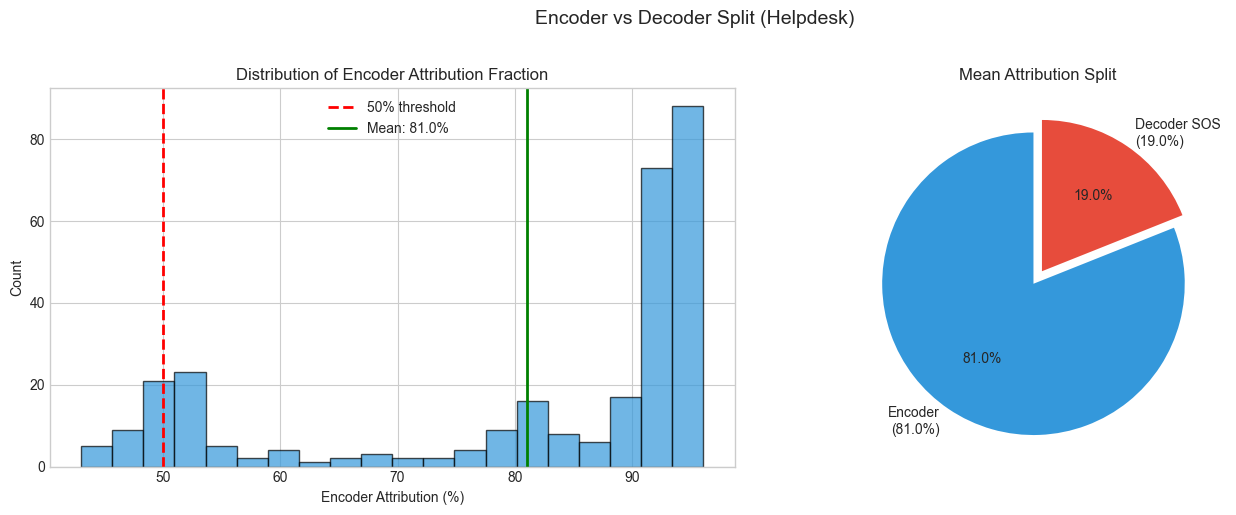

In [8]:
# Histogram of encoder fraction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(split_df['encoder_fraction']*100, bins=20, edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.axvline(x=split_df['encoder_fraction'].mean()*100, color='green', linestyle='-', linewidth=2, 
           label=f"Mean: {split_df['encoder_fraction'].mean()*100:.1f}%")
ax.set_xlabel('Encoder Attribution (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Encoder Attribution Fraction')
ax.legend()

# Pie chart of mean split
ax = axes[1]
sizes = [split_df['encoder_fraction'].mean(), split_df['decoder_sos_fraction'].mean()]
labels = [f"Encoder\n({sizes[0]*100:.1f}%)", f"Decoder SOS\n({sizes[1]*100:.1f}%)"]
colors = ['#3498db', '#e74c3c']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
ax.set_title('Mean Attribution Split')

plt.suptitle(f'Encoder vs Decoder Split ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5b. Per-Feature Encoder vs Decoder Split

This section breaks down the encoder/decoder split by individual features. For example, how much does "Activity" in the encoder contribute vs "Activity" in the decoder (SOS token)?

In [9]:
# Per-feature encoder vs decoder breakdown - Summary table
feature_summary = feature_split_df.groupby('feature').agg({
    'encoder_attribution': 'mean',
    'decoder_attribution': 'mean',
    'encoder_fraction': 'mean',
    'total_attribution': 'mean'
}).round(4)

# Add percentage columns
feature_summary['encoder_pct'] = (feature_summary['encoder_fraction'] * 100).round(1)
feature_summary['decoder_pct'] = (100 - feature_summary['encoder_pct']).round(1)

# Sort by total attribution
feature_summary = feature_summary.sort_values('total_attribution', ascending=False)

print("Per-Feature Encoder vs Decoder Split:")
print("="*80)
print(f"{'Feature':<25} {'Encoder':>12} {'Decoder':>12} {'Enc %':>8} {'Dec %':>8}")
print("-"*80)
for feat in feature_summary.index:
    row = feature_summary.loc[feat]
    print(f"{feat:<25} {row['encoder_attribution']:>12.4f} {row['decoder_attribution']:>12.4f} {row['encoder_pct']:>7.1f}% {row['decoder_pct']:>7.1f}%")
print("="*80)

Per-Feature Encoder vs Decoder Split:
Feature                        Encoder      Decoder    Enc %    Dec %
--------------------------------------------------------------------------------
Activity                        0.3254       0.2828    55.8%    44.2%
Variant index                   0.4440       0.0000   100.0%     0.0%
customer                        0.2699       0.0000   100.0%     0.0%
Resource                        0.1504       0.1043    59.7%    40.3%
responsible_section             0.1643       0.0000   100.0%     0.0%
service_type                    0.1347       0.0000   100.0%     0.0%
service_level                   0.1288       0.0000   100.0%     0.0%
product                         0.1239       0.0000   100.0%     0.0%
event_elapsed_time              0.0468       0.0727    48.2%    51.8%
support_section                 0.1138       0.0000   100.0%     0.0%
case_elapsed_time               0.0584       0.0504    50.0%    50.0%
workgroup                       0.0605   

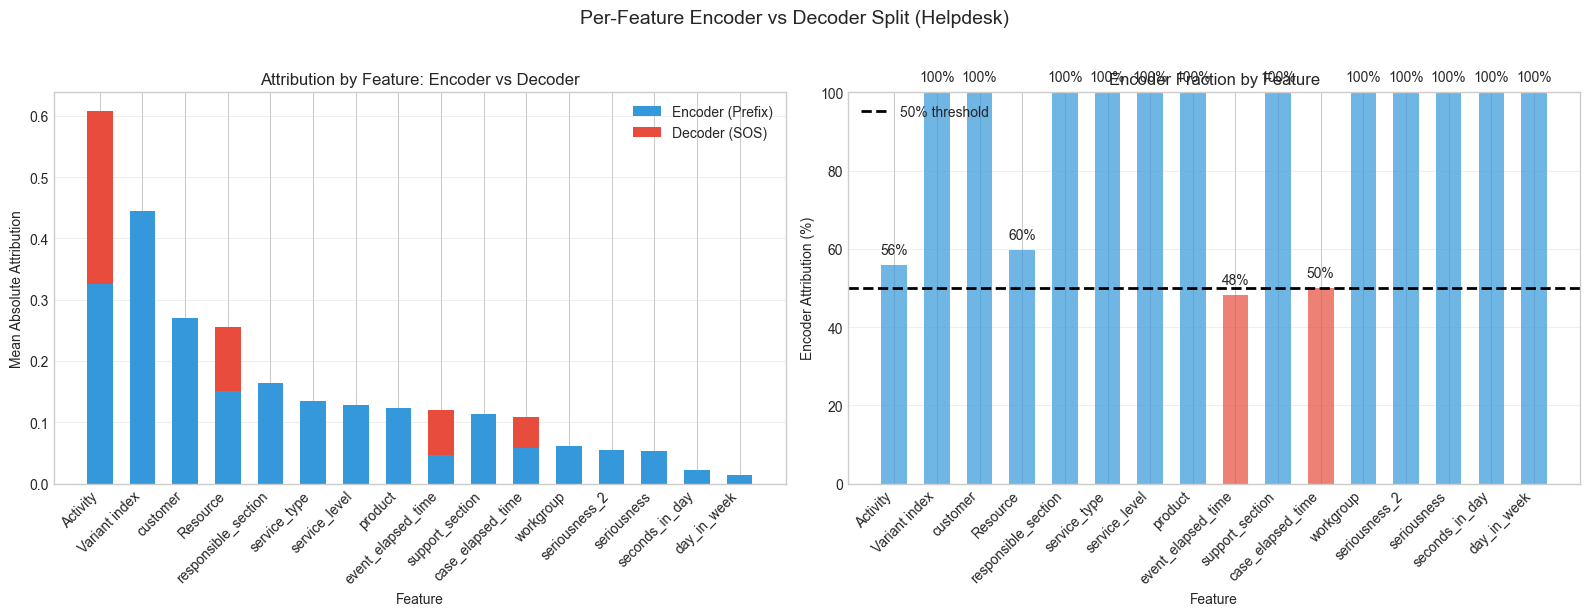

In [10]:
# Stacked bar chart: Encoder vs Decoder by Feature
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute attribution by feature (stacked)
ax = axes[0]
features = feature_summary.index.tolist()
x = np.arange(len(features))
width = 0.6

enc_vals = feature_summary['encoder_attribution'].values
dec_vals = feature_summary['decoder_attribution'].values

ax.bar(x, enc_vals, width, label='Encoder (Prefix)', color='#3498db')
ax.bar(x, dec_vals, width, bottom=enc_vals, label='Decoder (SOS)', color='#e74c3c')

ax.set_xlabel('Feature')
ax.set_ylabel('Mean Absolute Attribution')
ax.set_title('Attribution by Feature: Encoder vs Decoder')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Encoder fraction by feature
ax = axes[1]
enc_fracs = feature_summary['encoder_pct'].values

colors = ['#3498db' if f > 50 else '#e74c3c' for f in enc_fracs]
bars = ax.bar(x, enc_fracs, width, color=colors, alpha=0.7)

ax.axhline(y=50, color='black', linestyle='--', linewidth=2, label='50% threshold')
ax.set_xlabel('Feature')
ax.set_ylabel('Encoder Attribution (%)')
ax.set_title('Encoder Fraction by Feature')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, enc_fracs)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Per-Feature Encoder vs Decoder Split ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

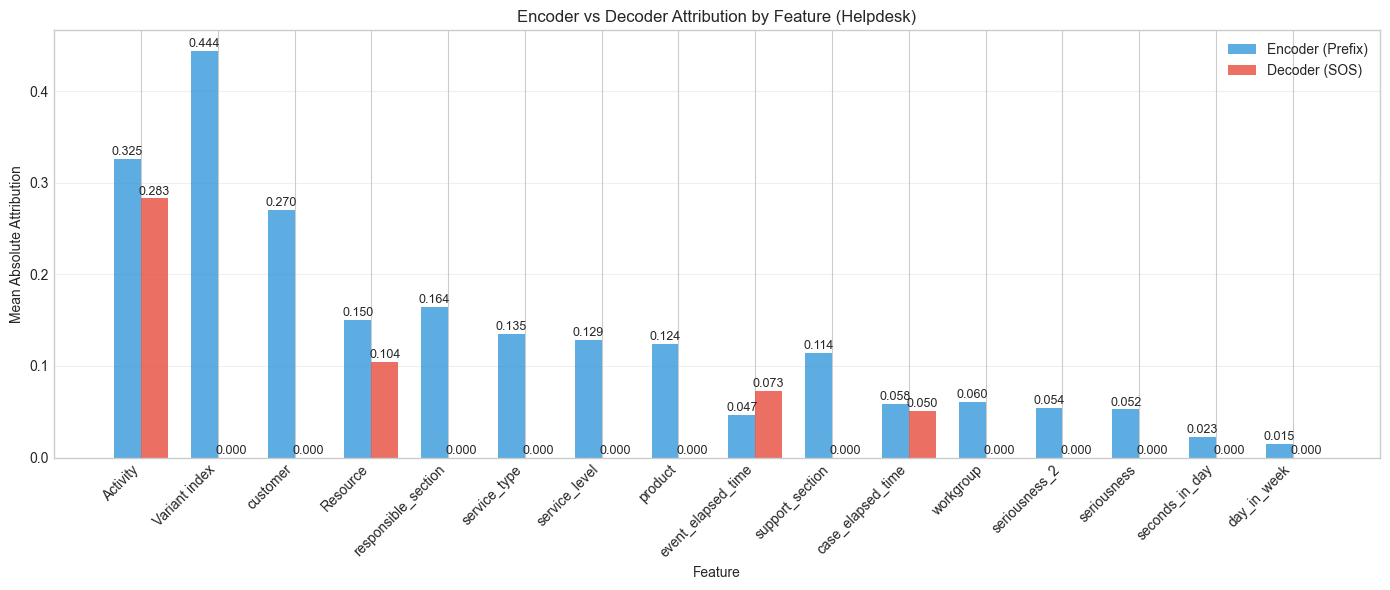

In [11]:
# Grouped bar chart: Side-by-side comparison
fig, ax = plt.subplots(figsize=(14, 6))

features = feature_summary.index.tolist()
x = np.arange(len(features))
width = 0.35

enc_vals = feature_summary['encoder_attribution'].values
dec_vals = feature_summary['decoder_attribution'].values

bars1 = ax.bar(x - width/2, enc_vals, width, label='Encoder (Prefix)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, dec_vals, width, label='Decoder (SOS)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Feature')
ax.set_ylabel('Mean Absolute Attribution')
ax.set_title(f'Encoder vs Decoder Attribution by Feature ({CONFIG.dataset_name})')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

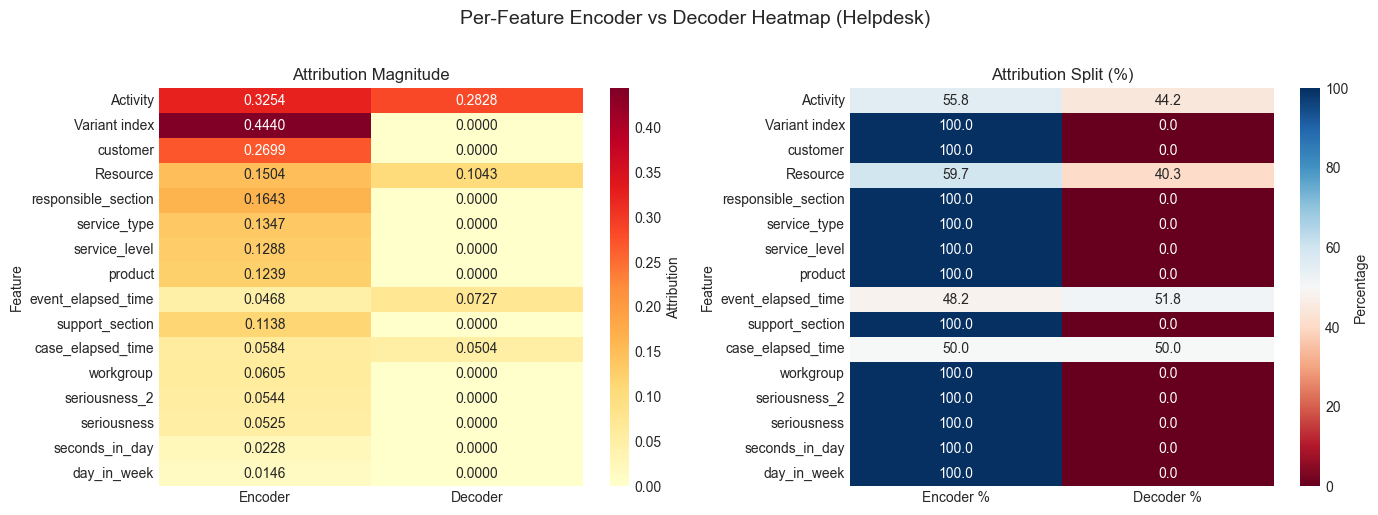

In [12]:
# Heatmap: Encoder vs Decoder attribution by feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create heatmap data
heatmap_data = pd.DataFrame({
    'Encoder': feature_summary['encoder_attribution'],
    'Decoder': feature_summary['decoder_attribution']
})

# Plot 1: Absolute values heatmap
ax = axes[0]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Attribution'})
ax.set_title('Attribution Magnitude')
ax.set_ylabel('Feature')

# Plot 2: Percentage split heatmap
ax = axes[1]
heatmap_pct = pd.DataFrame({
    'Encoder %': feature_summary['encoder_pct'],
    'Decoder %': feature_summary['decoder_pct']
})
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='RdBu', ax=ax, center=50,
            vmin=0, vmax=100, cbar_kws={'label': 'Percentage'})
ax.set_title('Attribution Split (%)')
ax.set_ylabel('Feature')

plt.suptitle(f'Per-Feature Encoder vs Decoder Heatmap ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

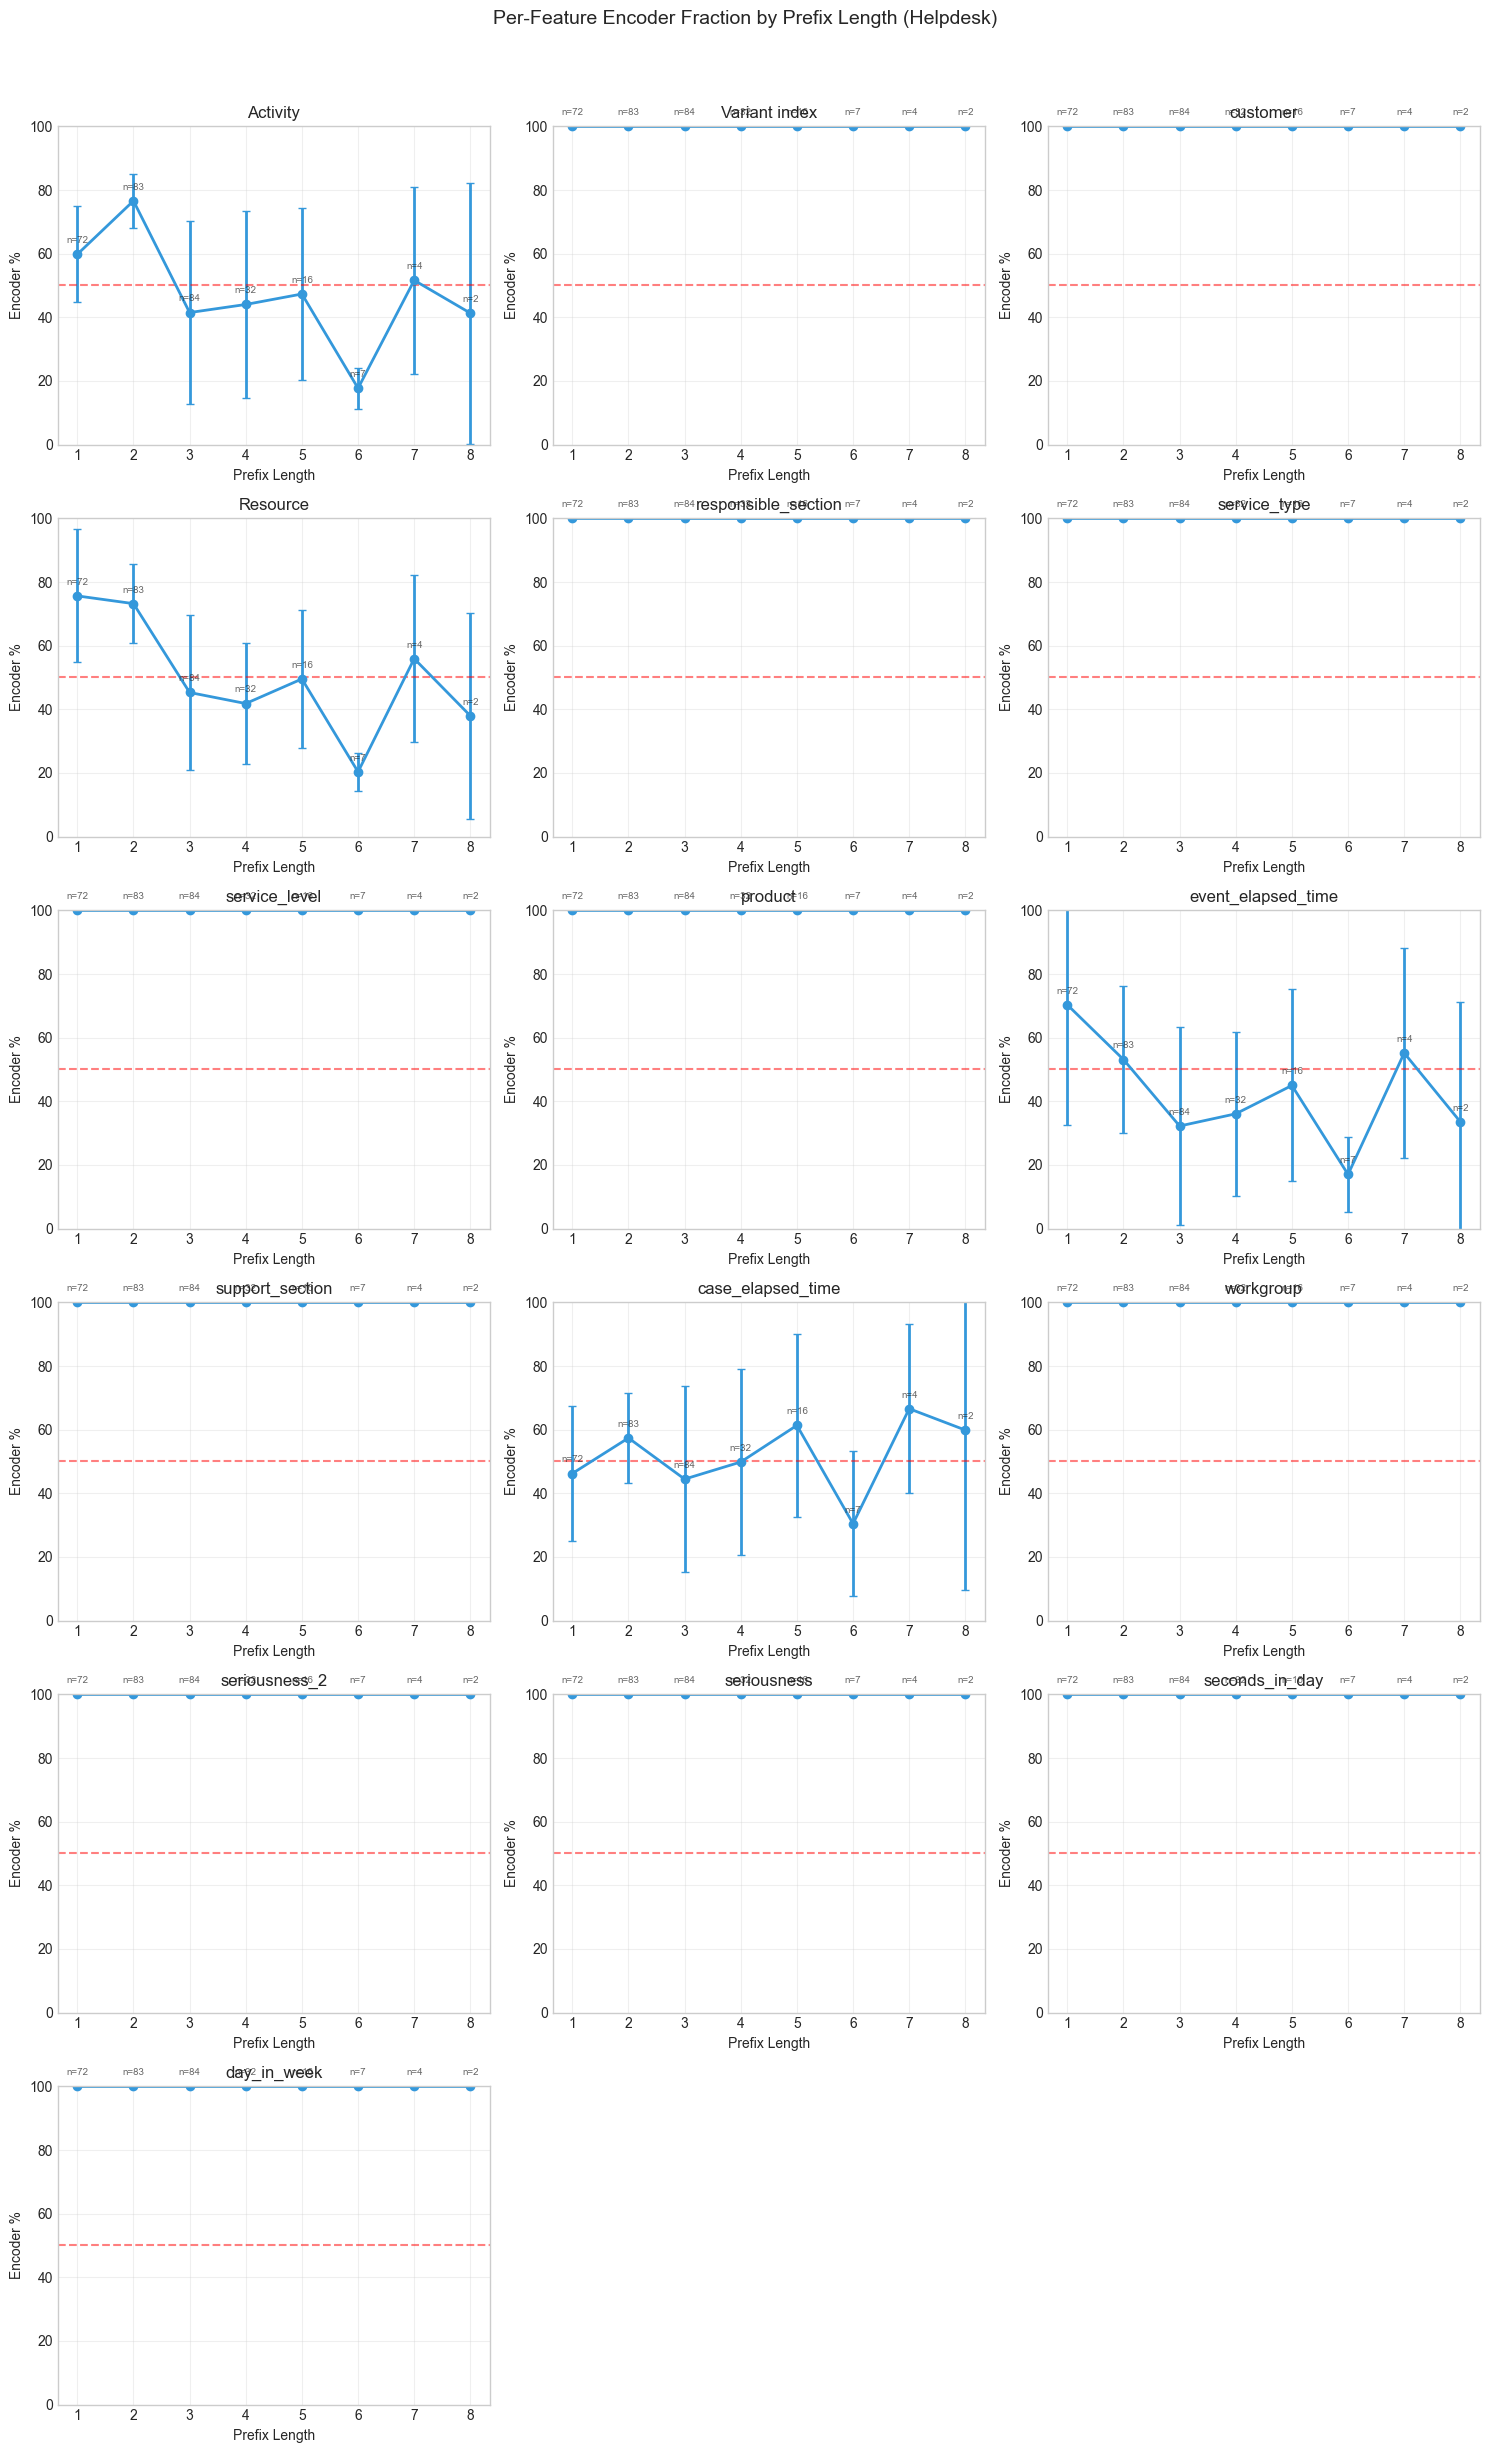


Sample distribution by prefix length:
  Prefix 1: n=72
  Prefix 2: n=83
  Prefix 3: n=84
  Prefix 4: n=32
  Prefix 5: n=16
  Prefix 6: n=7
  Prefix 7: n=4
  Prefix 8: n=2


In [13]:
# Per-feature encoder fraction by prefix length
features_to_plot = feature_summary.index.tolist()
n_features = len(features_to_plot)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

# Get sample counts per prefix length (from overall split_df)
prefix_counts = split_df.groupby('prefix_len').size()

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Filter to this feature
    feat_df = feature_split_df[feature_split_df['feature'] == feat]
    grouped = feat_df.groupby('prefix_len')['encoder_fraction'].agg(['mean', 'std'])
    
    ax.errorbar(grouped.index, grouped['mean']*100, yerr=grouped['std']*100,
                marker='o', capsize=3, linewidth=2, markersize=6, color='#3498db')
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Prefix Length')
    ax.set_ylabel('Encoder %')
    ax.set_title(f'{feat}')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    
    # Add sample count annotations
    for pl in grouped.index:
        n = prefix_counts.get(pl, 0)
        ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']*100), 
                    textcoords="offset points", xytext=(0, 8), 
                    ha='center', fontsize=7, alpha=0.7)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Per-Feature Encoder Fraction by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print sample distribution
print("\nSample distribution by prefix length:")
for pl in sorted(prefix_counts.index):
    print(f"  Prefix {pl}: n={prefix_counts[pl]}")

## 6. Split by Prefix Length

In [14]:
# Group by prefix length
by_prefix_len = split_df.groupby('prefix_len').agg({
    'encoder_fraction': ['mean', 'std', 'count'],
    'decoder_sos_fraction': ['mean', 'std'],
    'total_attribution': ['mean', 'std']
})

print("Encoder/Decoder Split by Prefix Length:")
print("="*60)
for prefix_len in sorted(split_df['prefix_len'].unique()):
    subset = split_df[split_df['prefix_len'] == prefix_len]
    print(f"Prefix {prefix_len}: Encoder {subset['encoder_fraction'].mean()*100:.1f}% ± {subset['encoder_fraction'].std()*100:.1f}% (n={len(subset)})")

Encoder/Decoder Split by Prefix Length:
Prefix 1: Encoder 90.1% ± 6.9% (n=72)
Prefix 2: Encoder 92.2% ± 3.3% (n=83)
Prefix 3: Encoder 70.2% ± 19.9% (n=84)
Prefix 4: Encoder 71.1% ± 18.8% (n=32)
Prefix 5: Encoder 74.7% ± 17.4% (n=16)
Prefix 6: Encoder 51.6% ± 7.7% (n=7)
Prefix 7: Encoder 76.9% ± 22.9% (n=4)
Prefix 8: Encoder 66.8% ± 32.0% (n=2)


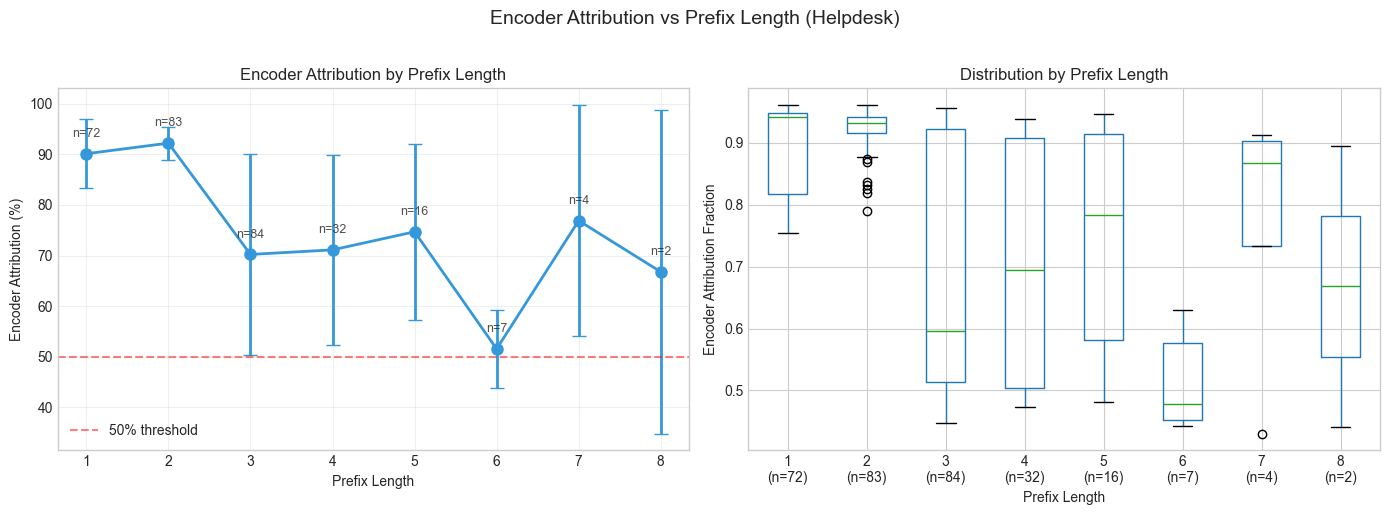

In [15]:
# Plot encoder fraction by prefix length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get sample counts per prefix length
prefix_counts = split_df.groupby('prefix_len').size()

# Line plot with error bars
ax = axes[0]
grouped = split_df.groupby('prefix_len')['encoder_fraction'].agg(['mean', 'std'])
ax.errorbar(grouped.index, grouped['mean']*100, yerr=grouped['std']*100, 
            marker='o', capsize=5, linewidth=2, markersize=8, color='#3498db')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Encoder Attribution (%)')
ax.set_title('Encoder Attribution by Prefix Length')
ax.legend()
ax.grid(True, alpha=0.3)

# Add sample count annotations
for pl in grouped.index:
    n = prefix_counts[pl]
    ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']*100), 
                textcoords="offset points", xytext=(0, 12), 
                ha='center', fontsize=9, alpha=0.8)

# Box plot with sample counts in x-axis labels
ax = axes[1]
split_df.boxplot(column='encoder_fraction', by='prefix_len', ax=ax)
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Encoder Attribution Fraction')

# Update x-tick labels to include sample counts
xlabels = [f'{int(pl)}\n(n={prefix_counts[pl]})' for pl in sorted(split_df['prefix_len'].unique())]
ax.set_xticklabels(xlabels)
ax.set_title('Distribution by Prefix Length')
plt.suptitle('')  # Remove auto title

plt.suptitle(f'Encoder Attribution vs Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

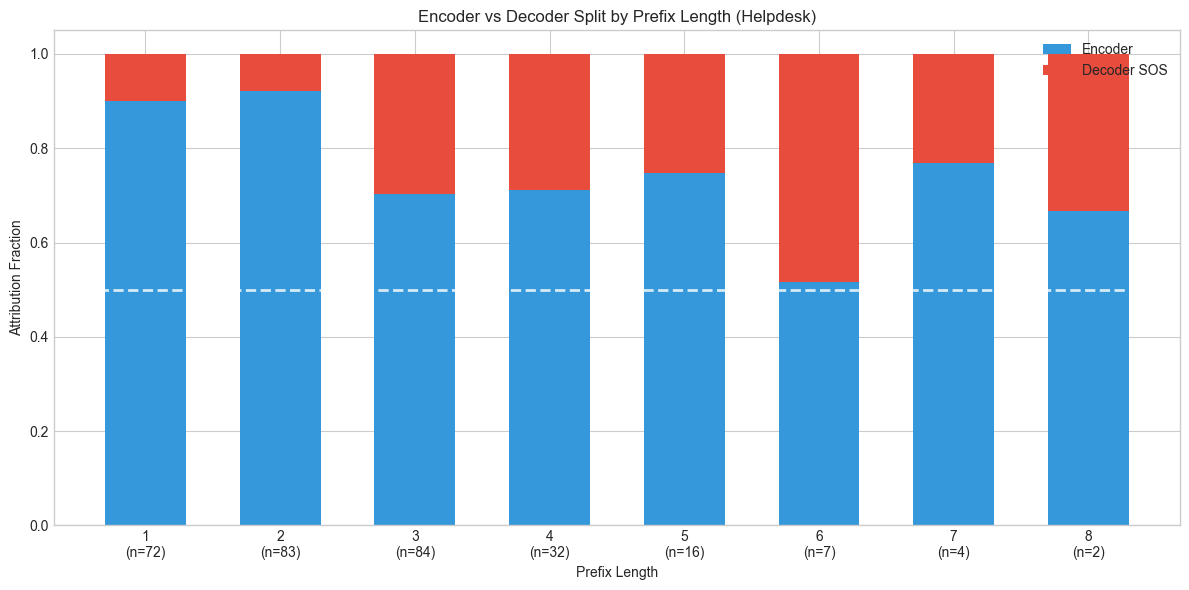

In [16]:
# Stacked bar chart showing encoder/decoder by prefix length
fig, ax = plt.subplots(figsize=(12, 6))

# Get sample counts per prefix length
prefix_counts = split_df.groupby('prefix_len').size()

grouped = split_df.groupby('prefix_len')[['encoder_fraction', 'decoder_sos_fraction']].mean()

x = np.arange(len(grouped))
width = 0.6

ax.bar(x, grouped['encoder_fraction'], width, label='Encoder', color='#3498db')
ax.bar(x, grouped['decoder_sos_fraction'], width, bottom=grouped['encoder_fraction'], 
       label='Decoder SOS', color='#e74c3c')

ax.set_xlabel('Prefix Length')
ax.set_ylabel('Attribution Fraction')
ax.set_title(f'Encoder vs Decoder Split by Prefix Length ({CONFIG.dataset_name})')

# X-tick labels with sample counts
xlabels = [f'{pl}\n(n={prefix_counts[pl]})' for pl in grouped.index]
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend()
ax.axhline(y=0.5, color='white', linestyle='--', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

## 7. Total Attribution by Prefix Length

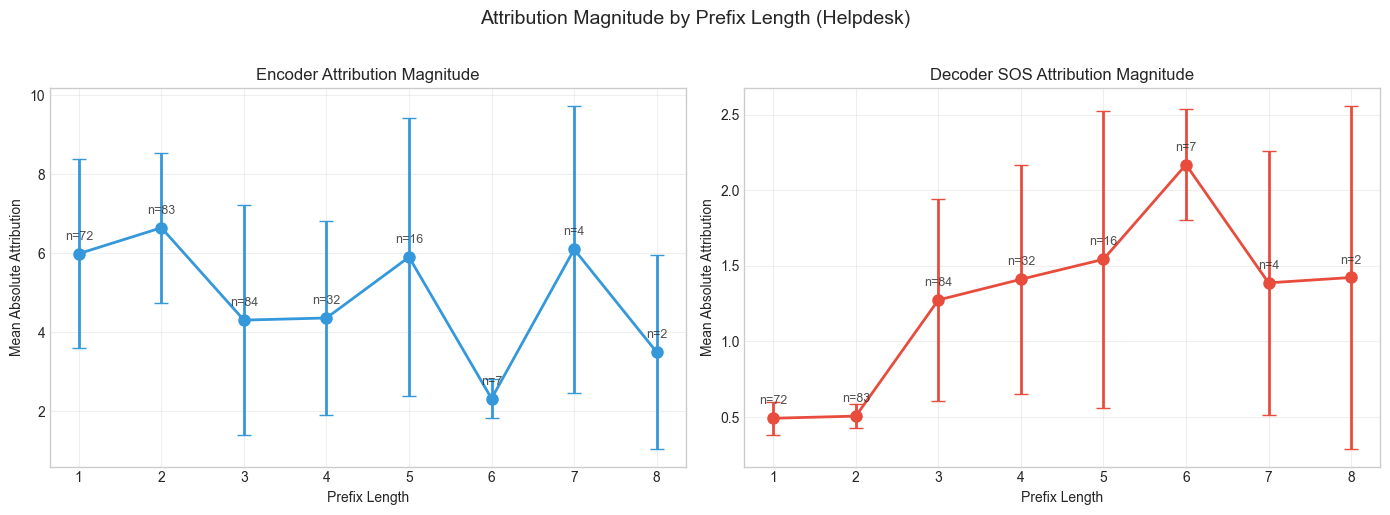

In [17]:
# Plot total attribution magnitude by prefix length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get sample counts per prefix length
prefix_counts = split_df.groupby('prefix_len').size()

# Encoder total
ax = axes[0]
grouped_enc = split_df.groupby('prefix_len')['encoder_total'].agg(['mean', 'std'])
ax.errorbar(grouped_enc.index, grouped_enc['mean'], yerr=grouped_enc['std'], 
            marker='o', capsize=5, linewidth=2, markersize=8, color='#3498db')
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Mean Absolute Attribution')
ax.set_title('Encoder Attribution Magnitude')
ax.grid(True, alpha=0.3)

# Add sample count annotations
for pl in grouped_enc.index:
    n = prefix_counts[pl]
    ax.annotate(f'n={n}', (pl, grouped_enc.loc[pl, 'mean']), 
                textcoords="offset points", xytext=(0, 10), 
                ha='center', fontsize=9, alpha=0.8)

# Decoder total
ax = axes[1]
grouped_dec = split_df.groupby('prefix_len')['decoder_sos_total'].agg(['mean', 'std'])
ax.errorbar(grouped_dec.index, grouped_dec['mean'], yerr=grouped_dec['std'], 
            marker='o', capsize=5, linewidth=2, markersize=8, color='#e74c3c')
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Mean Absolute Attribution')
ax.set_title('Decoder SOS Attribution Magnitude')
ax.grid(True, alpha=0.3)

# Add sample count annotations
for pl in grouped_dec.index:
    n = prefix_counts[pl]
    ax.annotate(f'n={n}', (pl, grouped_dec.loc[pl, 'mean']), 
                textcoords="offset points", xytext=(0, 10), 
                ha='center', fontsize=9, alpha=0.8)

plt.suptitle(f'Attribution Magnitude by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Save Results

In [18]:
# Save results
output_dir = CONFIG.get_results_dir()

mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'encoder_decoder_split{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'split_df': split_df,
        'feature_split_df': feature_split_df,  # NEW: per-feature breakdown
        'feature_summary': feature_summary,     # NEW: per-feature summary
        'by_prefix_len': by_prefix_len,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/helpdesk/encoder_decoder_split_test.pkl


## 9. Summary

In [19]:
print("="*80)
print(f"SUMMARY: Encoder vs Decoder Split Analysis")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(split_df)}")

print(f"\n--- Overall Split ---")
print(f"Mean encoder fraction: {split_df['encoder_fraction'].mean()*100:.1f}%")
print(f"Mean decoder fraction: {split_df['decoder_sos_fraction'].mean()*100:.1f}%")

print(f"\n--- Per-Feature Encoder vs Decoder Split ---")
for feat in feature_summary.index:
    row = feature_summary.loc[feat]
    print(f"  {feat:<25}: Encoder {row['encoder_pct']:.1f}% | Decoder {row['decoder_pct']:.1f}%")

print(f"\n--- Key Findings ---")
if split_df['encoder_fraction'].mean() > 0.7:
    print("- Predictions are ENCODER-DOMINATED: The model relies heavily on prefix information.")
elif split_df['encoder_fraction'].mean() < 0.3:
    print("- Predictions are DECODER-DOMINATED: The model relies heavily on autoregressive generation.")
else:
    print("- Predictions use a BALANCED MIX of encoder and decoder information.")

# Check if encoder fraction increases with prefix length
correlation = split_df['prefix_len'].corr(split_df['encoder_fraction'])
if correlation > 0.3:
    print(f"- Encoder importance INCREASES with prefix length (correlation: {correlation:.2f})")
elif correlation < -0.3:
    print(f"- Encoder importance DECREASES with prefix length (correlation: {correlation:.2f})")
else:
    print(f"- No strong relationship between prefix length and encoder importance (correlation: {correlation:.2f})")

# Per-feature insights
most_encoder_feat = feature_summary['encoder_pct'].idxmax()
most_decoder_feat = feature_summary['encoder_pct'].idxmin()
print(f"\n- Most encoder-driven feature: {most_encoder_feat} ({feature_summary.loc[most_encoder_feat, 'encoder_pct']:.1f}% from encoder)")
print(f"- Most decoder-driven feature: {most_decoder_feat} ({feature_summary.loc[most_decoder_feat, 'decoder_pct']:.1f}% from decoder)")

SUMMARY: Encoder vs Decoder Split Analysis

Dataset: Helpdesk
Mode: TEST
Samples analyzed: 300

--- Overall Split ---
Mean encoder fraction: 81.0%
Mean decoder fraction: 19.0%

--- Per-Feature Encoder vs Decoder Split ---
  Activity                 : Encoder 55.8% | Decoder 44.2%
  Variant index            : Encoder 100.0% | Decoder 0.0%
  customer                 : Encoder 100.0% | Decoder 0.0%
  Resource                 : Encoder 59.7% | Decoder 40.3%
  responsible_section      : Encoder 100.0% | Decoder 0.0%
  service_type             : Encoder 100.0% | Decoder 0.0%
  service_level            : Encoder 100.0% | Decoder 0.0%
  product                  : Encoder 100.0% | Decoder 0.0%
  event_elapsed_time       : Encoder 48.2% | Decoder 51.8%
  support_section          : Encoder 100.0% | Decoder 0.0%
  case_elapsed_time        : Encoder 50.0% | Decoder 50.0%
  workgroup                : Encoder 100.0% | Decoder 0.0%
  seriousness_2            : Encoder 100.0% | Decoder 0.0%
  seriousne